# Local and Global Extrema

A guided notebook on **maxima**, **minima**, and how to find them with derivatives.

This notebook explains:
- what local and global extrema are
- critical points and the **first-derivative test**
- the **second-derivative test** for classifying critical points
- finding **global extrema** on a closed interval $[a,b]$

This notebook follows the same style template as the uploaded guidelines.

## 1. Introduction

Phrases like *"minimize costs"* or *"maximize space"* are often read as simple synonyms for *decrease* and *increase*. But in calculus **minimize** and **maximize** refer to particular values of a function.

- A **minimum** is the smallest value a function $f$ can output.
- A **maximum** is the largest value.
- Together they are called **extrema**.

We can often *estimate* extrema by looking at a graph, but to find them **precisely** we use derivatives. After this notebook you will be able to:
- locate critical points by setting $f'(x) = 0$,
- classify them as minima or maxima with the second-derivative test,
- find the global maximum and minimum on a closed interval.

## 2. Definition of Local Extrema

Given a function $f$ and an arbitrarily small positive value $\delta > 0$:

- $f$ has a **local minimum** at $x_0$ if
$$
f(x_0) \le f(x) \quad \text{for all } x \in (x_0 - \delta,\; x_0 + \delta).
$$

- $f$ has a **local maximum** at $x_0$ if
$$
f(x_0) \ge f(x) \quad \text{for all } x \in (x_0 - \delta,\; x_0 + \delta).
$$

In words: $x_0$ is a local minimum if $f(x_0)$ is the smallest value in a small neighbourhood around $x_0$, and a local maximum if it is the largest.

> **Note.** Extrema are *actual output values* of the function, not absolute magnitudes. On an interval where $f$ takes both signs, a minimum can be negative while a maximum is positive.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

## 3. Critical Points and the First-Derivative Test

Suppose $f(x_0)$ is a local minimum. Then $f$ **decreases** on $(x_0 - \delta, x_0)$ and **increases** on $(x_0, x_0 + \delta)$. So $x_0$ is exactly the point where the function switches from decreasing to increasing (and the reverse for a local maximum).

The derivative $f'(x_0)$ is the slope of the tangent line at $x_0$. So:

- if $f'(x_0) > 0$, then $f$ is **increasing** at $x_0$;
- if $f'(x_0) < 0$, then $f$ is **decreasing** at $x_0$;
- if $f'(x_0) = 0$, then $x_0$ is a **critical point** — the graph is momentarily flat.

A critical point could be a local minimum, a local maximum, or neither — we need more information to decide.

### Example

$$
f(x) = \tfrac{1}{3}x^3 - x \quad\Longrightarrow\quad f'(x) = x^2 - 1.
$$

Evaluating the slope at a few points:

- $f'(2) = 2^2 - 1 = 3 > 0$ &nbsp;→&nbsp; increasing at $x = 2$
- $f'\!\left(\tfrac{1}{2}\right) = \left(\tfrac{1}{2}\right)^2 - 1 = -\tfrac{3}{4} < 0$ &nbsp;→&nbsp; decreasing at $x = \tfrac{1}{2}$
- $f'(1) = 1^2 - 1 = 0$ &nbsp;→&nbsp; critical point at $x = 1$

In [2]:
x = sp.symbols('x')
f = sp.Rational(1, 3)*x**3 - x
fp = sp.diff(f, x)

print("f(x)  =", f)
print("f'(x) =", fp)
for point in [2, sp.Rational(1, 2), 1]:
    print(f"  f'({point}) = {fp.subs(x, point)}")

f(x)  = x**3/3 - x
f'(x) = x**2 - 1
  f'(2) = 3
  f'(1/2) = -3/4
  f'(1) = 0


## 4. The Second-Derivative Test

Just as the first derivative tells us whether $f$ is increasing or decreasing, the **second derivative** tells us whether $f'$ is increasing or decreasing at a critical point.

At a critical point $x_0$ (where $f'(x_0) = 0$):

| Condition | Conclusion |
|-----------|------------|
| $f''(x_0) > 0$ | local **minimum** at $x_0$ |
| $f''(x_0) < 0$ | local **maximum** at $x_0$ |
| $f''(x_0) = 0$ | test **fails** — could be min, max, or neither |

**Intuition:** if $f''(x_0) > 0$, the slope $f'$ is going from negative to positive, so the curve turns upward → a valley (minimum). If $f''(x_0) < 0$, the slope goes from positive to negative → a peak (maximum).

### Back to the example

$$
f(x) = \tfrac{1}{3}x^3 - x \;\Longrightarrow\; f'(x) = x^2 - 1 \;\Longrightarrow\; f''(x) = 2x.
$$

Find **all** critical points:

$$
f'(x) = x^2 - 1 = 0 \;\Longrightarrow\; x = \pm 1.
$$

So the critical points are $\left(-1, \tfrac{2}{3}\right)$ and $\left(1, -\tfrac{2}{3}\right)$. Apply the second-derivative test:

$$
f''(1) = 2(1) = 2 > 0 \;\Rightarrow\; \text{minimum}, \qquad
f''(-1) = 2(-1) = -2 < 0 \;\Rightarrow\; \text{maximum}.
$$

Therefore $f$ has a **local minimum** at $\left(1, -\tfrac{2}{3}\right)$ and a **local maximum** at $\left(-1, \tfrac{2}{3}\right)$.

In [3]:
fpp = sp.diff(f, x, 2)
critical_points = sp.solve(fp, x)
print("f''(x) =", fpp)
print("critical x-values:", critical_points)
print()

for c in critical_points:
    second = fpp.subs(x, c)
    kind = 'minimum' if second > 0 else 'maximum' if second < 0 else 'test fails'
    print(f"x = {c}: f(x) = {f.subs(x, c)}, f''(x) = {second}  ->  {kind}")

f''(x) = 2*x
critical x-values: [-1, 1]

x = -1: f(x) = 2/3, f''(x) = -2  ->  maximum
x = 1: f(x) = -2/3, f''(x) = 2  ->  minimum


### Visualizing the critical points

Let us plot $f(x) = \tfrac{1}{3}x^3 - x$ and mark its local maximum and minimum.

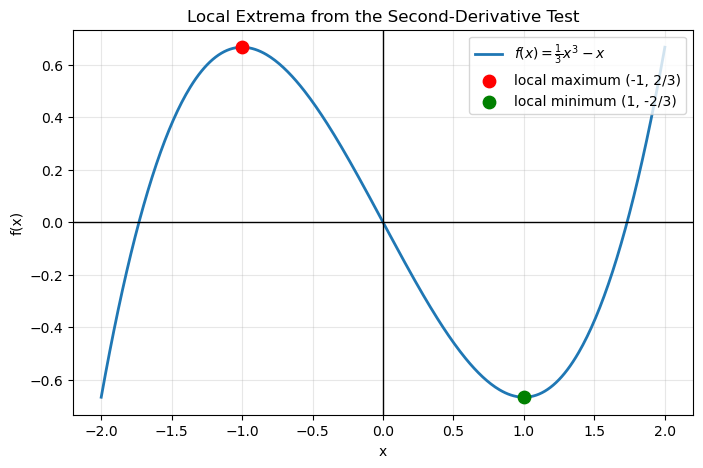

In [4]:
xs = np.linspace(-2, 2, 400)
ys = (1/3)*xs**3 - xs

plt.figure(figsize=(8, 5))
plt.plot(xs, ys, label=r"$f(x) = \frac{1}{3}x^3 - x$", linewidth=2)
plt.scatter([-1], [2/3], color='red',   s=80, zorder=5, label='local maximum (-1, 2/3)')
plt.scatter([ 1], [-2/3], color='green', s=80, zorder=5, label='local minimum (1, -2/3)')
plt.title('Local Extrema from the Second-Derivative Test')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.axhline(0, lw=1, color='black')
plt.axvline(0, lw=1, color='black')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

> **Watch the interval.** If we only looked at the interval $[-0.5, 1.5]$, the local maximum at $x = -1$ would lie outside it. Given an interval $[a, b]$, **discard any critical point with $x \notin [a, b]$** before applying the second-derivative test.

## 5. Global Extrema vs. Local Extrema

A **local** extremum is only extreme in a small neighbourhood. A **global** (or **absolute**) extremum is the largest/smallest value over an *entire interval*.

Consider

$$
f(x) = x^4 - x^2 \;\Longrightarrow\; f'(x) = 4x^3 - 2x = 0 \;\Longrightarrow\; x = 0,\; \pm\tfrac{1}{\sqrt{2}}.
$$

So there are three critical points: $\left(-\tfrac{1}{\sqrt{2}}, -\tfrac{1}{4}\right)$, $(0, 0)$, and $\left(\tfrac{1}{\sqrt{2}}, -\tfrac{1}{4}\right)$.

The second derivative is $f''(x) = 12x^2 - 2$, giving

$$
f''\!\left(-\tfrac{1}{\sqrt{2}}\right) > 0, \qquad f''(0) < 0, \qquad f''\!\left(\tfrac{1}{\sqrt{2}}\right) > 0.
$$

Thus there are two **local minima** at $\left(\pm\tfrac{1}{\sqrt{2}}, -\tfrac{1}{4}\right)$ and a **local maximum** at $(0, 0)$. Notice that the local maximum $f(0) = 0$ is **not** the largest value of the function — the curve rises higher away from the origin.

In [5]:
g = x**4 - x**2
gp = sp.diff(g, x)
gpp = sp.diff(g, x, 2)

crit = sp.solve(gp, x)
print("f'(x)  =", gp)
print("f''(x) =", gpp)
print()
for c in crit:
    second = gpp.subs(x, c)
    kind = 'minimum' if second > 0 else 'maximum' if second < 0 else 'test fails'
    print(f"x = {sp.nsimplify(c)} (~{float(c):+.3f}): "
          f"f = {sp.nsimplify(g.subs(x, c))}, f'' = {float(second):+.2f}  ->  {kind}")

f'(x)  = 4*x**3 - 2*x
f''(x) = 2*(6*x**2 - 1)

x = 0 (~+0.000): f = 0, f'' = -2.00  ->  maximum
x = -sqrt(2)/2 (~-0.707): f = -1/4, f'' = +4.00  ->  minimum
x = sqrt(2)/2 (~+0.707): f = -1/4, f'' = +4.00  ->  minimum


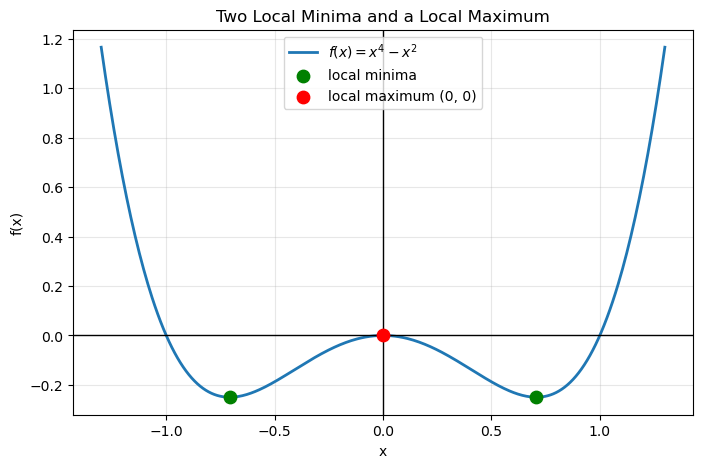

In [6]:
xs = np.linspace(-1.3, 1.3, 400)
ys = xs**4 - xs**2
r = 1/np.sqrt(2)

plt.figure(figsize=(8, 5))
plt.plot(xs, ys, label=r"$f(x) = x^4 - x^2$", linewidth=2)
plt.scatter([-r, r], [-0.25, -0.25], color='green', s=80, zorder=5, label='local minima')
plt.scatter([0], [0], color='red', s=80, zorder=5, label='local maximum (0, 0)')
plt.title('Two Local Minima and a Local Maximum')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.axhline(0, lw=1, color='black')
plt.axvline(0, lw=1, color='black')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## 6. Global Extrema on a Closed Interval

To find the global maximum and minimum of $f$ on a closed interval $[a, b]$:

1. Find the critical points and **keep only those inside $[a, b]$**.
2. Evaluate $f$ at those critical points.
3. Evaluate $f$ at the **endpoints** $f(a)$ and $f(b)$.
4. The largest of all these values is the global maximum; the smallest is the global minimum.

### Example

Take $f(x) = x^4 - x^2$ on $[0, 1.5]$. Since $-\tfrac{1}{\sqrt{2}} < 0$ lies outside the interval, only two critical points remain: $(0, 0)$ and $\left(\tfrac{1}{\sqrt{2}}, -\tfrac{1}{4}\right)$.

Evaluate at the endpoints:

$$
f(0) = 0, \qquad f(1.5) = 1.5^4 - 1.5^2 = 2.8125.
$$

Since $f(1.5) > f(0) > f\!\left(\tfrac{1}{\sqrt{2}}\right)$, the function has a **global maximum** at $x = 1.5$ and a **global minimum** at $x = \tfrac{1}{\sqrt{2}} \approx 0.707$.

(Here $x = 0$ is both a critical point and an endpoint, so only three values need to be compared.)

In [7]:
a, b = 0, 1.5

# critical points inside [a, b], plus the endpoints
candidates = [c for c in crit if a <= float(c) <= b] + [sp.Float(a), sp.Float(b)]

evaluated = [(float(c), float(g.subs(x, c))) for c in candidates]
for xv, yv in sorted(evaluated):
    print(f"x = {xv:6.3f}   f(x) = {yv:7.4f}")

xmax, ymax = max(evaluated, key=lambda p: p[1])
xmin, ymin = min(evaluated, key=lambda p: p[1])
print()
print(f"Global maximum: f({xmax:.3f}) = {ymax:.4f}")
print(f"Global minimum: f({xmin:.3f}) = {ymin:.4f}")

x =  0.000   f(x) =  0.0000
x =  0.000   f(x) =  0.0000
x =  0.707   f(x) = -0.2500
x =  1.500   f(x) =  2.8125

Global maximum: f(1.500) = 2.8125
Global minimum: f(0.707) = -0.2500


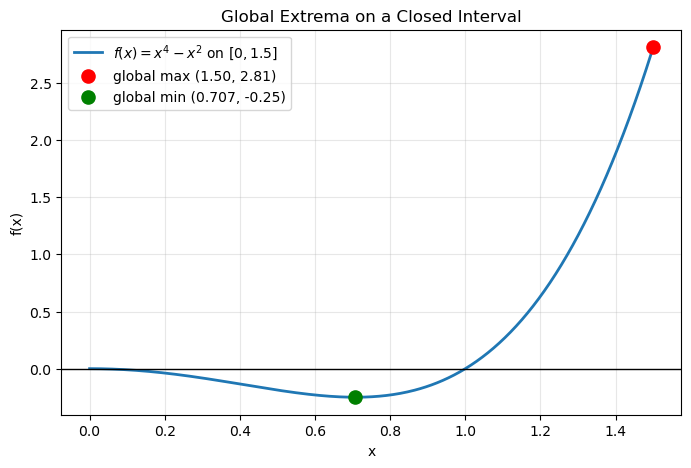

In [8]:
xs = np.linspace(0, 1.5, 400)
ys = xs**4 - xs**2

plt.figure(figsize=(8, 5))
plt.plot(xs, ys, label=r"$f(x) = x^4 - x^2$ on $[0, 1.5]$", linewidth=2)
plt.scatter([xmax], [ymax], color='red',   s=90, zorder=5, label=f'global max ({xmax:.2f}, {ymax:.2f})')
plt.scatter([xmin], [ymin], color='green', s=90, zorder=5, label=f'global min ({xmin:.3f}, {ymin:.2f})')
plt.title('Global Extrema on a Closed Interval')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.axhline(0, lw=1, color='black')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## 7. Summary of the Procedure

To analyse the extrema of a function $f$ on an interval $[a, b]$:

1. **Differentiate:** compute $f'(x)$.
2. **Critical points:** solve $f'(x) = 0$; discard solutions outside $[a, b]$.
3. **Classify:** use $f''$ on each critical point — $f'' > 0$ → minimum, $f'' < 0$ → maximum, $f'' = 0$ → inconclusive.
4. **Endpoints:** evaluate $f(a)$ and $f(b)$.
5. **Compare:** the largest value among critical points and endpoints is the global maximum; the smallest is the global minimum.

## 8. Exercises

### Basic

1. Find the critical points of $f(x) = x^2 - 4x + 3$ and classify them.
2. Find the critical points of $f(x) = x^3 - 3x$ and classify each with the second-derivative test.

### Intermediate

3. For $f(x) = x^3 - 3x$, find the global maximum and minimum on the interval $[0, 2]$.
4. Show that $f(x) = x^3$ has a critical point at $x = 0$ where the second-derivative test fails, and decide whether it is an extremum.

### Advanced

5. A rectangular pen is built against a wall with $20$ m of fencing for the three remaining sides. If the width is $x$, the area is $A(x) = x(20 - 2x)$. Find the width that **maximizes** the area, and the maximum area.

## 9. Solutions / Checks

**1.** $f'(x) = 2x - 4 = 0 \Rightarrow x = 2$. Since $f''(x) = 2 > 0$, it is a local **minimum** at $(2, -1)$.

**2.** $f'(x) = 3x^2 - 3 = 0 \Rightarrow x = \pm 1$. With $f''(x) = 6x$: $f''(1) = 6 > 0$ → minimum at $(1, -2)$; $f''(-1) = -6 < 0$ → maximum at $(-1, 2)$.

**3.** On $[0, 2]$, the only interior critical point is $x = 1$ (where $f = -2$). Endpoints: $f(0) = 0$, $f(2) = 2$. So the global **maximum** is $f(2) = 2$ and the global **minimum** is $f(1) = -2$.

**4.** $f'(x) = 3x^2 = 0 \Rightarrow x = 0$, and $f''(0) = 0$, so the test fails. But $f(x) = x^3$ is increasing on both sides of $0$ (it changes sign without turning around), so $x = 0$ is an **inflection point**, not an extremum.

**5.** $A(x) = 20x - 2x^2$, $A'(x) = 20 - 4x = 0 \Rightarrow x = 5$. Since $A''(x) = -4 < 0$, this is a maximum. The width is $x = 5$ m and the maximum area is $A(5) = 5 \cdot 10 = 50\ \text{m}^2$.

Run the cell below to verify these symbolically.

In [9]:
x = sp.symbols('x')

def analyse(expr, interval=None):
    fp = sp.diff(expr, x)
    fpp = sp.diff(expr, x, 2)
    crit = sp.solve(fp, x)
    print(f"f(x) = {expr}")
    for c in crit:
        if interval and not (interval[0] <= float(c) <= interval[1]):
            continue
        s = fpp.subs(x, c)
        kind = 'minimum' if s > 0 else 'maximum' if s < 0 else 'test fails'
        print(f"   x = {c}: f = {expr.subs(x, c)}, f'' = {s}  ->  {kind}")
    if interval:
        for endpoint in interval:
            print(f"   endpoint x = {endpoint}: f = {expr.subs(x, endpoint)}")
    print()

analyse(x**2 - 4*x + 3)
analyse(x**3 - 3*x)
analyse(x**3 - 3*x, interval=(0, 2))
analyse(20*x - 2*x**2)

f(x) = x**2 - 4*x + 3
   x = 2: f = -1, f'' = 2  ->  minimum

f(x) = x**3 - 3*x
   x = -1: f = 2, f'' = -6  ->  maximum
   x = 1: f = -2, f'' = 6  ->  minimum

f(x) = x**3 - 3*x
   x = 1: f = -2, f'' = 6  ->  minimum
   endpoint x = 0: f = 0
   endpoint x = 2: f = 2

f(x) = -2*x**2 + 20*x
   x = 5: f = 50, f'' = -4  ->  maximum



## 10. Conclusion

To sum up:

- A **local minimum** is the least value $f(x_0)$ in a small interval near $x_0$; a **local maximum** is the largest. Together they are **local extrema**.
- The **first-derivative test** tells us whether $f$ is increasing or decreasing. A **critical point** is where $f$ is defined but neither increasing nor decreasing — found by solving $f'(x) = 0$.
- The **second-derivative test** classifies a critical point: $f'' > 0$ → minimum, $f'' < 0$ → maximum, $f'' = 0$ → inconclusive.
- To find **global (absolute) extrema** on $[a, b]$, compare the function values at the in-interval critical points with the values at the endpoints $f(a)$ and $f(b)$.

Key lesson:

$$
f'(x_0) = 0 \;\text{locates candidates}, \qquad f''(x_0) \;\text{tells their type}, \qquad \text{endpoints decide the global winner.}
$$